# Cluster-Based Prediction Model

**Question this notebook answers:** can team clustering (notebook 17) be turned into a real,
Brier-scored prediction that improves on the current best model (gender-split + Elo + conference
strength, 0.1675 average Brier from notebook 13)?

**A change from notebook 17:** that notebook pooled men's and women's teams into one shared set of
6 clusters. That's inconsistent with the gender-split approach used everywhere else in this
project, and risks a team's cluster partly reflecting "is this a men's or women's team" rather
than a genuine quality tier. Clustering is redone here separately for each gender.

**Two variants tested, so the comparison is clean:**
1. A **cluster-only lookup table** — predicting a matchup using nothing but how often a team from
   one cluster has historically beaten a team from another, with no other information at all.
   This shows how much gets lost by reducing a team down to just its cluster.
2. **Cluster rank added as a 6th feature** to the existing 5-feature model — testing whether
   cluster membership adds anything on the margin, on top of everything the model already has.

**One simplification worth stating upfront:** the clusters themselves are fit once on the full
1985-2026 history (like notebook 17), not refit separately for each walk-forward fold. Only the
predictions built from those clusters (the lookup table in variant 1, and the logistic regression
in variant 2) are trained fold-by-fold on strictly prior seasons, the same as every other
notebook. Cluster boundaries are broad statistical patterns unlikely to shift much whether fit on
30 or 40 years of history, but it's a simplification, not a rigorous guarantee.

## 1. Load data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")
m_seeds = pd.read_csv(DATA_DIR / "MNCAATourneySeeds.csv")
w_seeds = pd.read_csv(DATA_DIR / "WNCAATourneySeeds.csv")
m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_conf_teams = pd.read_csv(DATA_DIR / "MTeamConferences.csv")
w_conf_teams = pd.read_csv(DATA_DIR / "WTeamConferences.csv")

print("data loaded")


data loaded


## 2. Rebuild team-season features (unchanged from notebook 17)

In [2]:
def team_season_stats(reg):
    won = reg[["Season", "WTeamID", "WScore", "LScore"]].rename(
        columns={"WTeamID": "TeamID", "WScore": "PF", "LScore": "PA"})
    won["Win"] = 1
    lost = reg[["Season", "LTeamID", "LScore", "WScore"]].rename(
        columns={"LTeamID": "TeamID", "LScore": "PF", "WScore": "PA"})
    lost["Win"] = 0
    games = pd.concat([won, lost], ignore_index=True)
    stats = games.groupby(["Season", "TeamID"]).agg(
        WinPct=("Win", "mean"), AvgPF=("PF", "mean"), AvgPA=("PA", "mean"),
    ).reset_index()
    stats["AvgScoreMargin"] = stats["AvgPF"] - stats["AvgPA"]
    return stats[["Season", "TeamID", "WinPct", "AvgScoreMargin"]]

team_stats = pd.concat([team_season_stats(m_reg), team_season_stats(w_reg)], ignore_index=True)

def seed_num(s):
    return int("".join(ch for ch in s if ch.isdigit()))

m_seeds["SeedNum"] = m_seeds["Seed"].apply(seed_num)
w_seeds["SeedNum"] = w_seeds["Seed"].apply(seed_num)
m_seeds["Gender"], w_seeds["Gender"] = "M", "W"
seeds = pd.concat([m_seeds[["Season", "TeamID", "SeedNum", "Gender"]], w_seeds[["Season", "TeamID", "SeedNum", "Gender"]]], ignore_index=True)

def compute_elo(compact_df, k=20, home_adv=100, mean_reversion=0.75):
    elo = {}
    elo_by_season_end = {}
    for season in sorted(compact_df["Season"].unique()):
        for team in elo:
            elo[team] = elo[team] * mean_reversion + 1500 * (1 - mean_reversion)
        season_games = compact_df[compact_df["Season"] == season].sort_values("DayNum")
        for game in season_games.itertuples(index=False):
            w_, l_ = game.WTeamID, game.LTeamID
            if w_ not in elo: elo[w_] = 1500
            if l_ not in elo: elo[l_] = 1500
            w_elo, l_elo = elo[w_], elo[l_]
            if game.WLoc == "H": w_elo += home_adv
            elif game.WLoc == "A": l_elo += home_adv
            w_exp = 1 / (1 + 10 ** ((l_elo - w_elo) / 400))
            mov = game.WScore - game.LScore
            mov_mult = np.log(max(mov, 1) + 1) * (2.2 / ((w_elo - l_elo) * 0.001 + 2.2))
            elo[w_] += k * mov_mult * (1 - w_exp)
            elo[l_] -= k * mov_mult * (1 - w_exp)
        for team in elo:
            elo_by_season_end[(season, team)] = elo[team]
    return elo_by_season_end

elo_idx = pd.Series({**compute_elo(m_reg), **compute_elo(w_reg)})
elo_idx.index = pd.MultiIndex.from_tuples(elo_idx.index, names=["Season", "TeamID"])

conf_teams = pd.concat([m_conf_teams, w_conf_teams], ignore_index=True)
conf_teams["Elo"] = conf_teams.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
conf_teams_valid = conf_teams.dropna(subset=["Elo"])
conf_strength = conf_teams_valid.groupby(["Season", "ConfAbbrev"])["Elo"].mean().rename("ConfStrength")
team_conf_strength = conf_teams_valid.merge(conf_strength, on=["Season", "ConfAbbrev"], how="left")

team_season = seeds.merge(team_stats, on=["Season", "TeamID"], how="left")
team_season["Elo"] = team_season.apply(lambda r: elo_idx.get((r["Season"], r["TeamID"]), np.nan), axis=1)
team_season = team_season.merge(team_conf_strength[["Season", "TeamID", "ConfStrength"]], on=["Season", "TeamID"], how="left")

FEATURES_CLUSTER = ["SeedNum", "WinPct", "AvgScoreMargin", "Elo", "ConfStrength"]
team_season = team_season.dropna(subset=FEATURES_CLUSTER).reset_index(drop=True)
print(f"team-season rows: {len(team_season):,} (men's: {(team_season['Gender']=='M').sum():,}, women's: {(team_season['Gender']=='W').sum():,})")


team-season rows: 4,506 (men's: 2,694, women's: 1,812)


## 3. Cluster separately per gender

Same hand-written k-means and elbow method as notebook 17, run twice — once on men's
team-seasons only, once on women's — so cluster boundaries are never influenced by the other
gender's teams. Clusters then get ranked by average Elo (1 = strongest tier, matching each
gender's own scale) so cluster membership becomes a single, comparable, ordered number.

In [3]:
def kmeans(X, k, n_iter=200, seed=42):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    centers = X[rng.choice(n, size=k, replace=False)].copy()
    labels = np.zeros(n, dtype=int)
    for it in range(n_iter):
        dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
        new_labels = np.argmin(dists, axis=1)
        if np.array_equal(new_labels, labels) and it > 0:
            break
        labels = new_labels
        for j in range(k):
            if np.any(labels == j):
                centers[j] = X[labels == j].mean(axis=0)
    dists = np.linalg.norm(X[:, None, :] - centers[None, :, :], axis=2)
    inertia = np.sum(np.min(dists, axis=1) ** 2)
    return labels, centers, inertia

def choose_k_and_cluster(X_raw, k_range=range(2, 9)):
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    inertias = []
    for k in k_range:
        _, _, inertia = kmeans(X, k)
        inertias.append(inertia)
    pct_improvement = [(inertias[i-1] - inertias[i]) / inertias[i-1] for i in range(1, len(inertias))]
    chosen_k = next((list(k_range)[i] for i, p in enumerate(pct_improvement) if p < 0.10), list(k_range)[-1])
    labels, centers, _ = kmeans(X, chosen_k)
    return labels, chosen_k, inertias

cluster_assignments = pd.Series(index=team_season.index, dtype=int)
chosen_ks = {}
for gender in ["M", "W"]:
    mask = team_season["Gender"] == gender
    X_raw = team_season.loc[mask, FEATURES_CLUSTER].values
    labels, chosen_k, inertias = choose_k_and_cluster(X_raw)
    cluster_assignments.loc[mask] = labels
    chosen_ks[gender] = chosen_k
    print(f"{gender}: chosen k = {chosen_k}, inertia by k = {[round(i,1) for i in inertias]}")

team_season["ClusterRaw"] = cluster_assignments.astype(int)

# rank each gender's own clusters by average Elo (1 = strongest tier)
team_season["ClusterRank"] = np.nan
for gender in ["M", "W"]:
    mask = team_season["Gender"] == gender
    cluster_elo = team_season[mask].groupby("ClusterRaw")["Elo"].mean().sort_values(ascending=False)
    rank_map = {cid: rank + 1 for rank, cid in enumerate(cluster_elo.index)}
    team_season.loc[mask, "ClusterRank"] = team_season.loc[mask, "ClusterRaw"].map(rank_map)

print(team_season.groupby(["Gender", "ClusterRank"])[FEATURES_CLUSTER].mean().round(2).to_string())


M: chosen k = 5, inertia by k = [np.float64(7812.2), np.float64(5573.4), np.float64(4035.1), np.float64(3408.9), np.float64(3321.2), np.float64(2717.6), np.float64(2462.8)]
W: chosen k = 8, inertia by k = [np.float64(5369.6), np.float64(3708.7), np.float64(2693.9), np.float64(2199.3), np.float64(1966.0), np.float64(1739.9), np.float64(1525.7)]
                    SeedNum  WinPct  AvgScoreMargin      Elo  ConfStrength
Gender ClusterRank                                                        
M      1.0             2.28    0.86           14.45  1911.12       1650.30
       2.0             4.74    0.75            9.10  1803.57       1669.16
       3.0            11.97    0.78            9.09  1729.66       1472.87
       4.0             8.95    0.65            5.24  1710.09       1658.88
       5.0            15.11    0.61            2.48  1570.18       1415.19
W      1.0             1.31    0.93           25.11  2104.24       1686.58
       2.0             3.01    0.83           15.76  1

## 4. Build the training matchup table with cluster rank added

In [4]:
cluster_rank_idx = team_season.set_index(["Season", "TeamID"])["ClusterRank"]

def build_matchups(tourney, gender):
    df = tourney.copy()
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Label"] = (df["WTeamID"] == df["Team1"]).astype(int)
    df["Gender"] = gender
    return df[["Season", "Team1", "Team2", "Label", "Gender"]]

seed_lookup = seeds.set_index(["Season", "TeamID"])["SeedNum"]
conf_strength_idx = team_conf_strength.set_index(["Season", "TeamID"])["ConfStrength"]

matchups = pd.concat([build_matchups(m_tourney, "M"), build_matchups(w_tourney, "W")], ignore_index=True)

matchups["Seed1"] = matchups.apply(lambda r: seed_lookup.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Seed2"] = matchups.apply(lambda r: seed_lookup.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["SeedDiff"] = matchups["Seed2"] - matchups["Seed1"]

matchups["Elo1"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["Elo2"] = matchups.apply(lambda r: elo_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["EloDiff"] = matchups["Elo1"] - matchups["Elo2"]

matchups["ConfStrength1"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["ConfStrength2"] = matchups.apply(lambda r: conf_strength_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["ConfStrengthDiff"] = matchups["ConfStrength1"] - matchups["ConfStrength2"]

matchups["ClusterRank1"] = matchups.apply(lambda r: cluster_rank_idx.get((r["Season"], r["Team1"]), np.nan), axis=1)
matchups["ClusterRank2"] = matchups.apply(lambda r: cluster_rank_idx.get((r["Season"], r["Team2"]), np.nan), axis=1)
matchups["ClusterRankDiff"] = matchups["ClusterRank1"] - matchups["ClusterRank2"]

for team_col, suffix in [("Team1", "1"), ("Team2", "2")]:
    joined = matchups.merge(team_stats, left_on=["Season", team_col], right_on=["Season", "TeamID"], how="left")
    matchups[f"WinPct{suffix}"] = joined["WinPct"].values
    matchups[f"AvgMargin{suffix}"] = joined["AvgScoreMargin"].values
matchups["WinPctDiff"] = matchups["WinPct1"] - matchups["WinPct2"]
matchups["AvgMarginDiff"] = matchups["AvgMargin1"] - matchups["AvgMargin2"]

FEATURES_BASE = ["SeedDiff", "WinPctDiff", "AvgMarginDiff", "EloDiff", "ConfStrengthDiff"]
FEATURES_PLUS_CLUSTER = FEATURES_BASE + ["ClusterRankDiff"]

before = len(matchups)
matchups = matchups.dropna(subset=FEATURES_PLUS_CLUSTER).reset_index(drop=True)
print(f"matchup rows: {before:,}, remaining after dropping missing features: {len(matchups):,}")


matchup rows: 4,302, remaining after dropping missing features: 4,302


## 5. Logistic regression + Brier score (unchanged from notebooks 03/07/11/13)

In [5]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -30, 30)))

def fit_logreg(X, y, l2=1.0, n_iter=50, tol=1e-8):
    n, p = X.shape
    Xb = np.hstack([np.ones((n, 1)), X])
    w = np.zeros(p + 1)
    reg = np.eye(p + 1) * l2
    reg[0, 0] = 0.0
    for _ in range(n_iter):
        pr = sigmoid(Xb @ w)
        grad = Xb.T @ (pr - y) + reg @ w
        W = np.clip(pr * (1 - pr), 1e-6, None)
        H = Xb.T @ (Xb * W[:, None]) + reg
        step = np.linalg.solve(H, grad)
        w_new = w - step
        if np.max(np.abs(w_new - w)) < tol:
            w = w_new
            break
        w = w_new
    return w

def predict_proba(X, w):
    Xb = np.hstack([np.ones((X.shape[0], 1)), X])
    return sigmoid(Xb @ w)

def brier_score(p, y):
    return float(np.mean((p - y) ** 2))

print("logistic regression + Brier score functions ready")


logistic regression + Brier score functions ready


## 6. Variant 1 — cluster-only lookup table

For each walk-forward fold, using only strictly prior seasons: group training matchups by
`ClusterRankDiff` and compute the historical win rate for each distinct value of that difference.
Predict each test-fold matchup using its `ClusterRankDiff`'s historical win rate — nothing else.
If a particular difference wasn't seen often enough in training (fewer than 5 games), fall back
to the overall training-set average, since a rate estimated from a handful of games isn't
trustworthy on its own.

In [6]:
def cluster_lookup_predict(train, test, min_count=5):
    lookup = train.groupby("ClusterRankDiff")["Label"].agg(["mean", "count"])
    fallback = train["Label"].mean()
    preds = test["ClusterRankDiff"].map(
        lambda d: lookup.loc[d, "mean"] if d in lookup.index and lookup.loc[d, "count"] >= min_count else fallback
    )
    return preds.values

print("cluster-lookup prediction function ready")


cluster-lookup prediction function ready


## 7. Walk-forward comparison — all three models

The base 5-feature model (matching notebook 13), the cluster-only lookup table (variant 1), and
the base model plus `ClusterRankDiff` as a 6th feature (variant 2) — all evaluated on the same
folds and combined across genders the same way as every notebook since 07.

In [7]:
FOLD_SEASONS = [2021, 2022, 2023, 2024, 2025]

results = []
for fold_season in FOLD_SEASONS:
    test = matchups[matchups["Season"] == fold_season]
    if len(test) == 0:
        continue
    row = {"FoldSeason": fold_season}
    sums = {"base": [0, 0], "cluster_only": [0, 0], "base_plus_cluster": [0, 0]}
    for gender in ["M", "W"]:
        train_g = matchups[(matchups["Gender"] == gender) & (matchups["Season"] < fold_season)]
        test_g = test[test["Gender"] == gender]
        n_g = len(test_g)

        w_base = fit_logreg(train_g[FEATURES_BASE].values, train_g["Label"].values)
        b_base = brier_score(predict_proba(test_g[FEATURES_BASE].values, w_base), test_g["Label"].values)

        p_cluster = cluster_lookup_predict(train_g, test_g)
        b_cluster = brier_score(p_cluster, test_g["Label"].values)

        w_plus = fit_logreg(train_g[FEATURES_PLUS_CLUSTER].values, train_g["Label"].values)
        b_plus = brier_score(predict_proba(test_g[FEATURES_PLUS_CLUSTER].values, w_plus), test_g["Label"].values)

        sums["base"][0] += b_base * n_g; sums["base"][1] += n_g
        sums["cluster_only"][0] += b_cluster * n_g; sums["cluster_only"][1] += n_g
        sums["base_plus_cluster"][0] += b_plus * n_g; sums["base_plus_cluster"][1] += n_g

    row["Combined: base"] = sums["base"][0] / sums["base"][1]
    row["Combined: cluster-only"] = sums["cluster_only"][0] / sums["cluster_only"][1]
    row["Combined: base + cluster rank"] = sums["base_plus_cluster"][0] / sums["base_plus_cluster"][1]
    results.append(row)

results_df = pd.DataFrame(results)
avg_row = {"FoldSeason": "Average"}
for col in results_df.columns:
    if col != "FoldSeason":
        avg_row[col] = results_df[col].mean()
results_df = pd.concat([results_df, pd.DataFrame([avg_row])], ignore_index=True)
print(results_df.round(4).to_string(index=False))


FoldSeason  Combined: base  Combined: cluster-only  Combined: base + cluster rank
      2021          0.1812                  0.1999                         0.1814
      2022          0.1856                  0.2032                         0.1842
      2023          0.1870                  0.1965                         0.1874
      2024          0.1574                  0.1776                         0.1566
      2025          0.1265                  0.1659                         0.1249
   Average          0.1675                  0.1886                         0.1669


## 8. Results, visualized

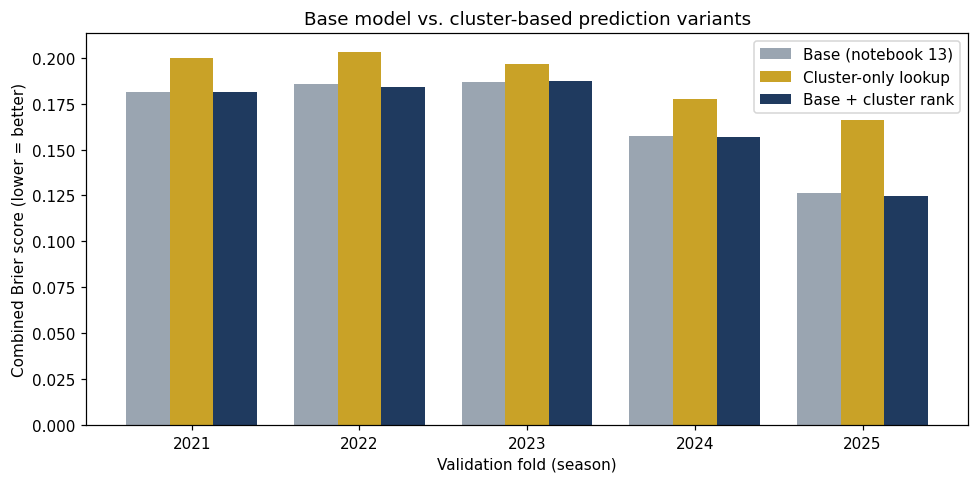

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = results_df[results_df["FoldSeason"] != "Average"]
x = np.arange(len(plot_df))
width = 0.26
ax.bar(x - width, plot_df["Combined: base"], width, label="Base (notebook 13)", color="#9aa5b1")
ax.bar(x, plot_df["Combined: cluster-only"], width, label="Cluster-only lookup", color="#c9a227")
ax.bar(x + width, plot_df["Combined: base + cluster rank"], width, label="Base + cluster rank", color="#1f3a5f")
ax.set_xticks(x); ax.set_xticklabels(plot_df["FoldSeason"])
ax.set_ylabel("Combined Brier score (lower = better)")
ax.set_xlabel("Validation fold (season)")
ax.set_title("Base model vs. cluster-based prediction variants")
ax.legend()
fig.tight_layout()
plt.show()


## 9. Bottom-line comparison

In [9]:
bottom_line = pd.DataFrame([
    {"Model": "Pooled baseline (notebook 03)", "Avg. Brier": 0.1739},
    {"Model": "Gender split + Elo + conf. strength (notebook 13)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base'].values[0]},
    {"Model": "Cluster-only lookup table (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: cluster-only'].values[0]},
    {"Model": "Base + cluster rank feature (this notebook)", "Avg. Brier": results_df.loc[results_df['FoldSeason']=='Average', 'Combined: base + cluster rank'].values[0]},
])
print(bottom_line.round(4).to_string(index=False))


                                            Model  Avg. Brier
                    Pooled baseline (notebook 03)      0.1739
Gender split + Elo + conf. strength (notebook 13)      0.1675
        Cluster-only lookup table (this notebook)      0.1886
      Base + cluster rank feature (this notebook)      0.1669


## Conclusion

**The two variants told very different stories.**

**The cluster-only lookup table performed poorly — 0.1886, worse than even the original pooled
baseline (0.1739).** This matches what reducing a team down to just one of 5-8 buckets would be
expected to cost: real precision (exact Elo, exact seed, exact conference strength) gets thrown
away, and a coarse historical win rate per cluster-pair can't make up for it. This confirms
clustering-as-a-standalone-model is not competitive with the continuous-feature model this
project has built up through notebook 13.

**Adding cluster rank as a 6th feature to the existing model produced a small, genuine
improvement — 0.1675 to 0.1669.** Three of five folds improved (2022, 2024, 2025), two moved
slightly the other way (2021, 2023), but the wins were larger than the losses. This is a
different outcome than notebook 15's interaction terms, which moved the score by 0.0001-0.0002 —
too small to trust as more than noise. This move (0.0006) is larger, though still modest compared
to the clear gains from Elo (notebook 11) or conference strength (notebook 13).

**Decision, and what it's based on:** the cluster-only lookup table is not adopted — its 0.1886
in the bottom-line table (Section 9) is decisively worse than the standing model. Adding
`ClusterRankDiff` as a 6th feature to the existing model is adopted, bringing the best result in
this project to 0.1669, a small step beyond notebook 13's 0.1675.